#**Import Libraries**





In [ ]:
# Data manipulation
import pandas as pd
import numpy as np
# Data visualization
import seaborn as sns
import matplotlib.pyplot as plt
# Text processing
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

# **Load the Dataset**

In this step, we load the Netflix Movies and TV Shows dataset using **pandas**.  
This dataset contains information about movies and TV shows such as title, genre, description, cast, country, and other metadata.

After loading the dataset, we display the dataframe to get an initial look at the data.

In [ ]:
df=pd.read_csv('/content/Netflix_movies_and_tv_shows_clustering.csv')
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...
...,...,...,...,...,...,...,...,...,...,...,...,...
7782,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...","October 19, 2020",2005,TV-MA,99 min,"Dramas, International Movies",When Lebanon's Civil War deprives Zozo of his ...
7783,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...
7784,s7785,Movie,Zulu Man in Japan,NaN,Nasty C,NaN,"September 25, 2020",2019,TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast..."
7785,s7786,TV Show,Zumbo's Just Desserts,NaN,"Adriano Zumbo, Rachel Khoo",Australia,"October 31, 2020",2019,TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...


# **Exploratory Data Analysis (EDA)**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2389
cast,718
country,507
date_added,10
release_year,0
rating,7
duration,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,release_year
count,7787.000000
mean,2013.932580
std,8.757395
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2018.000000
max,2021.000000


# **Preprocessing**

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2389
cast,718
country,507
date_added,10
release_year,0
rating,7
duration,0


In [ ]:
#percentage of missing values in 'director' column
missing_director_percentage = (df['director'].isnull().sum() / len(df)) * 100
print(f"Percentage of missing values in 'director' column: {missing_director_percentage:.2f}%")

Percentage of missing values in 'director' column: 30.68%


In [ ]:
# Handling the missing values in 'director','cast','country'
df[['director','cast','country']] = df[['director','cast','country']].fillna('Unknown')

In [ ]:
df['rating'].unique()

array(['TV-MA', 'R', 'PG-13', 'TV-14', 'TV-PG', 'NR', 'TV-G', 'TV-Y', nan,
       'TV-Y7', 'PG', 'G', 'NC-17', 'TV-Y7-FV', 'UR'], dtype=object)

In [ ]:
# Handling the missing values in 'rating' column
df['rating']=df['rating'].fillna('NR')

In [ ]:
#handling date_added column
# 1. Strip whitespace from the strings
df['date_added'] = df['date_added'].str.strip()

# 2. Convert to datetime
# We don't use errors='coerce' yet so we can see if there are actual errors,
# but usually, stripping is enough for this dataset.
df['date_added'] = pd.to_datetime(df['date_added'])

# 3. Check the null count again
print(df['date_added'].isnull().sum())

10


In [ ]:
df.dropna(subset=['date_added'], inplace=True)

In [ ]:
# df['listed_in']

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [ ]:
df['rating'].isnull().sum()

np.int64(0)

# **Analysis**

**Top Genres by Content Type (Movies vs TV Shows)**

In this section, we analyze the most common genres for **Movies** and **TV Shows** on Netflix.

Steps:
- Group the dataset by **content type** and **genre**
- Count the number of titles in each genre
- Select the **top 5 genres** for each content type
- Visualize the comparison using a horizontal bar chart

In [ ]:
df_exploded = df.explode('listed_in')
genre_by_type = (df_exploded
    .groupby(['type','listed_in'])
    .size()
    .reset_index(name='count')
    .sort_values(['type','count'], ascending=[True,False])
)

top_genres = genre_by_type.groupby('type').head(5)

print(top_genres)

        type                                          listed_in  count
173    Movie                                      Documentaries    334
263    Movie                                    Stand-Up Comedy    321
204    Movie                       Dramas, International Movies    320
133    Movie             Comedies, Dramas, International Movies    243
197    Movie   Dramas, Independent Movies, International Movies    215
414  TV Show                                           Kids' TV    204
405  TV Show                  International TV Shows, TV Dramas    111
330  TV Show  Crime TV Shows, International TV Shows, TV Dramas    106
425  TV Show                              Kids' TV, TV Comedies     89
387  TV Show  International TV Shows, Romantic TV Shows, TV ...     86


<Figure size 1200x1000 with 0 Axes>

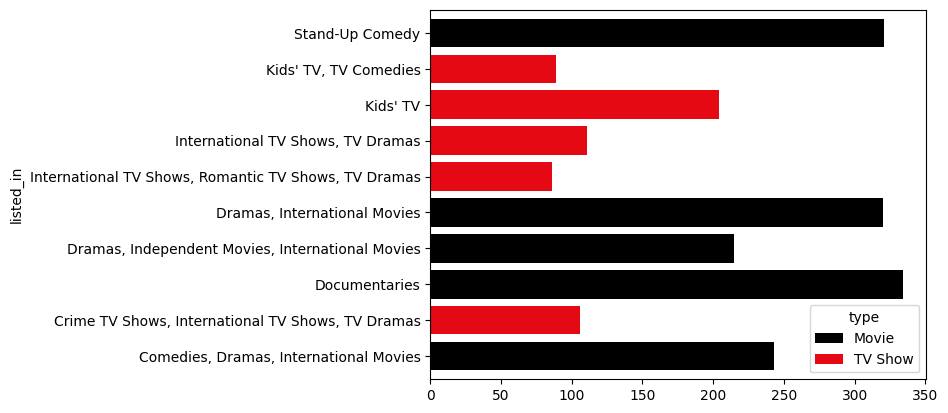

In [ ]:
pivot_df = top_genres.pivot(index='listed_in', columns='type', values='count').fillna(0)

plt.figure(figsize=(12,10))

# Plot horizontal bar chart with Netflix colors
bars = pivot_df.plot(
    kind='barh',
    color=['#000000', '#E50914'],  # TV Show , Movie
    edgecolor='none',
    stacked=True,
    width=0.8

)
plt.show()

## Distribution of Content Ratings

In this step, we analyze the distribution of **content ratings** (e.g., TV-MA, PG, R) in the dataset.

This helps us understand the **target audience** of Netflix content

/tmp/ipykernel_14542/2930467329.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


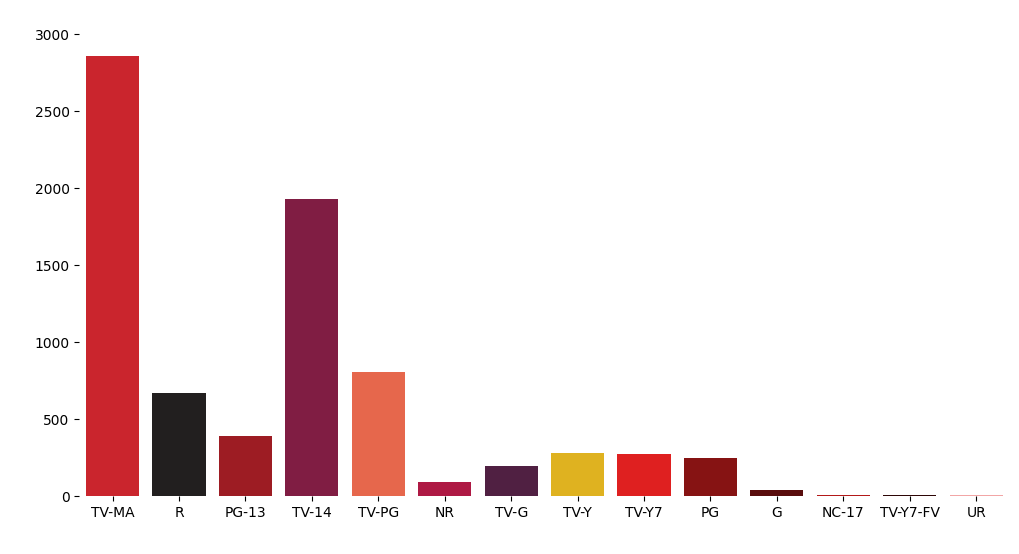

In [ ]:
# plt.figure(figsize=(10,5))
# # Count the number of titles for each rating
# sns.countplot(x='rating',data=df,palette=['#E50914'])
# plt.title("Distribution of Content Ratings")
# plt.xlabel("Rating")
# plt.ylabel("Count")

# plt.show()
plt.figure(figsize=(12,6))

unique_ratings = df['rating'].nunique()  # عدد التقييمات الفريد
palette_colors = ['#E50914', '#221F1F', '#B20710', '#900C3F', '#FF5733', '#C70039',
                  '#581845', '#FFC300', '#FF0000', '#990000', '#660000', '#CC0000', '#330000', '#FF9999'][:unique_ratings]

sns.countplot(
    x='rating',
    data=df,
    palette=palette_colors
)

plt.title("Distribution of Content Ratings", fontsize=16, fontweight='bold', color='white')
plt.xlabel("Rating", fontsize=14, fontweight='bold', color='white')
plt.ylabel("Count", fontsize=14, fontweight='bold', color='white')

sns.despine(left=True, bottom=True)

plt.show()

## **Description Length Analysis**

Here we analyze the **length of movie and TV show descriptions**.

Steps:
- Calculate the number of words in each description
- Compute the **average description length**
- Identify **very short descriptions**
- Visualize the distribution

In [ ]:
# Count number of words in each description
df['des_word_count']=df['description'].apply(lambda x: len(x.split()))
# Calculate the average description length
mean_words=df['des_word_count'].mean()
print("Average number of words in description:", round(mean_words, 2))

Average number of words in description: 23.83


In [ ]:
# Identify descriptions shorter than 15 words
short_desc=df[df['des_word_count']<15]
print("Number of very short descriptions:", short_desc.shape[0])
print("Percentage:", round((short_desc.shape[0] / df.shape[0]) * 100, 2), "%")

Number of very short descriptions: 10
Percentage: 0.13 %


## **Percentage of Short Descriptions**

This visualization shows the proportion of **short descriptions** compared to normal ones.

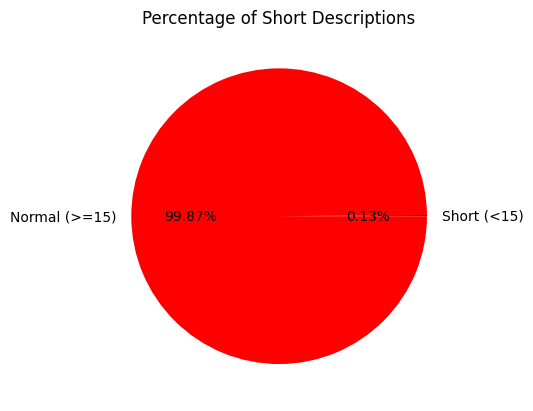

In [ ]:
short_count = short_desc.shape[0]
normal_count = df.shape[0] - short_count
plt.figure()
plt.pie([short_count, normal_count],
        labels=['Short (<15)', 'Normal (>=15)'],
        autopct='%1.2f%%',
        colors=['black', 'red'])

plt.title("Percentage of Short Descriptions")
plt.show()

##**Distribution of Description Length**

This histogram shows how description lengths are distributed across the dataset

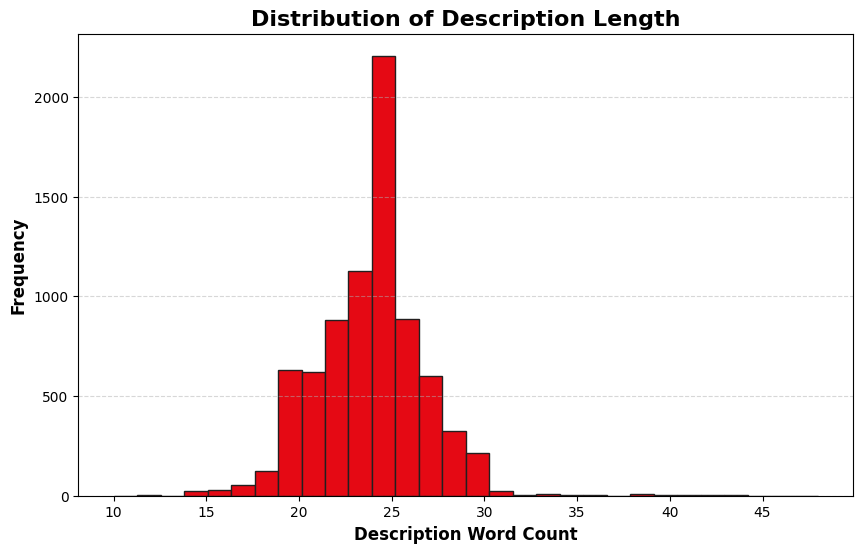

In [ ]:
# plt.hist(df['des_word_count'], bins=30)
# plt.xlabel("Description Word Count")
# plt.ylabel("Frequency")
# plt.title("Distribution of Description Length")
# plt.show()

plt.figure(figsize=(10,6))
plt.hist(df['des_word_count'], bins=30, color='#E50914', edgecolor='#221F1F')  # أحمر Netflix مع حواف سوداء
plt.xlabel("Description Word Count", fontsize=12, fontweight='bold')
plt.ylabel("Frequency", fontsize=12, fontweight='bold')
plt.title("Distribution of Description Length", fontsize=16, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)  # شبكات خفيفة للشكل
plt.show()

## **1-What is the precise breakdown between 'Movie' and 'TV Show' content types in the library?**

In [ ]:
type_counts = df['type'].value_counts()
type_counts

,count
type,
Movie,5377
TV Show,2400


In [ ]:
type_percentages = df['type'].value_counts(normalize=True) * 100
print("\nPercentages:\n", type_percentages)


Percentages:
 type
Movie      69.139771
TV Show    30.860229
Name: proportion, dtype: float64


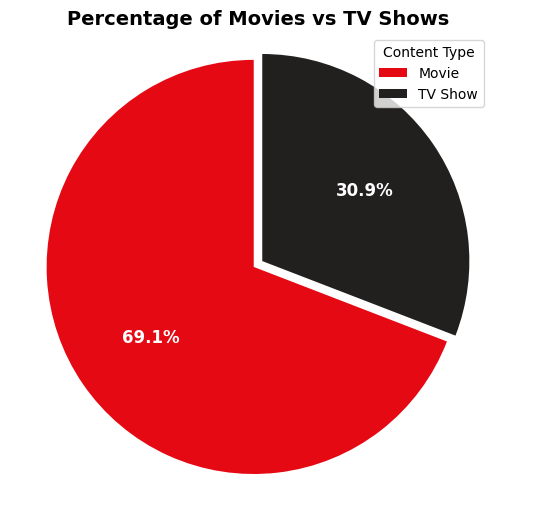

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))

colors = ['#E50914', '#221F1F']
explode = (0.05, 0)

type_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    startangle=90,
    labels=type_counts.index,
    textprops={
        'fontsize':12,
        'fontweight':'bold',
        'color':'white'
    }
)

plt.title("Percentage of Movies vs TV Shows",
          fontsize=14,
          fontweight='bold')

plt.ylabel("")
plt.axis('equal')

plt.legend(title="Content Type", loc="upper right")
plt.show()

**Movies account for approximately ` 69.1% ` of the library, while TV Shows represent about ` 30.9% `.**
**This indicates that the platform is predominantly ` movie-focused `.**

## **2-How does the content mix (Movie vs. TV Show) vary across the top 5 producing countries?**

In [ ]:
df['country'] = df['country'].str.split(', ')
df = df.explode('country')

In [ ]:
top_countries = df['country'].value_counts().head(5)
top_countries

,count
country,
United States,3290
India,990
United Kingdom,721
Unknown,506
Canada,412


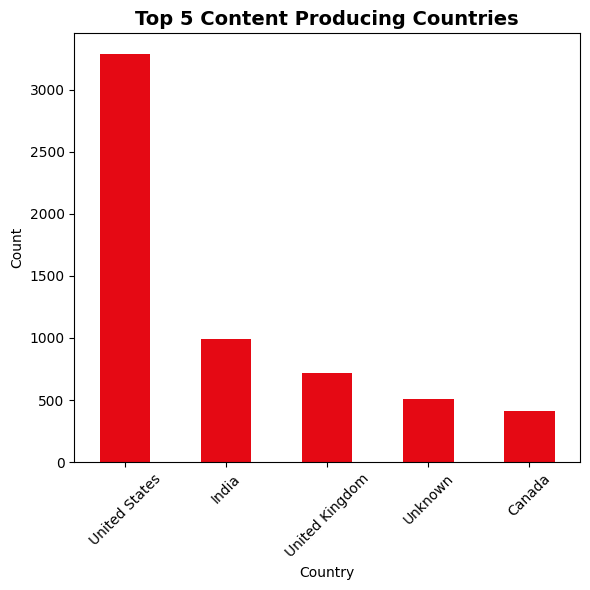

In [ ]:
plt.figure(figsize=(6,6))

top_countries.plot(
    kind='bar',
    color='#E50914'
)

plt.title("Top 5 Content Producing Countries",
          fontsize=14,
          fontweight='bold')

plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
top_countries = df['country'].value_counts().head(5).index

filtered_df = df[df['country'].isin(top_countries)]

content_count = pd.crosstab(filtered_df['country'], filtered_df['type'])

content_count

type,Movie,TV Show
country,,
Canada,286,126
India,915,75
United Kingdom,466,255
United States,2430,860
Unknown,230,276


<Figure size 1000x800 with 0 Axes>

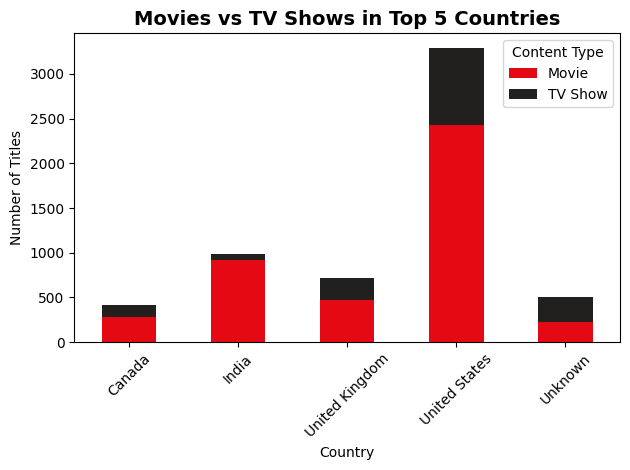

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

content_count.plot(
    kind='bar',
    stacked=True,
    color=['#E50914', '#221F1F']
)

plt.title("Movies vs TV Shows in Top 5 Countries",
          fontsize=14,
          fontweight='bold')

plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)
plt.legend(title="Content Type")

plt.tight_layout()
plt.show()

**-United States leads the library with 3,290 titles, making it the dominant content producer on the platform.**

**-India contributes 990 titles, with content being overwhelmingly movie-focused.**

**-The United Kingdom provides 721 titles and shows a relatively balanced mix of movies and TV shows.**

**-Overall, movies significantly outnumber TV shows across all top countries, indicating that the platform is largely movie-oriented.**

**By analyzing the 'description' field, what are the most common themes or keywords (e.g., "based on a true story," "love," "mystery," "revenge")?**

## **Top 10 Genres**

In [ ]:
df['listed_in'].astype(str)

,listed_in
0,"International TV Shows, TV Dramas, TV Sci-Fi &..."
1,"Dramas, International Movies"
2,"Horror Movies, International Movies"
3,"Action & Adventure, Independent Movies, Sci-Fi..."
4,Dramas
...,...
7784,"Documentaries, International Movies, Music & M..."
7785,"International TV Shows, Reality TV"
7786,"Documentaries, Music & Musicals"
7786,"Documentaries, Music & Musicals"


In [ ]:
genres = df['listed_in'].astype(str).str.split(', ').explode().str.strip()
genres = genres.str.replace(r"[\[\]'\"']", '', regex=True).str.strip()

In [ ]:
top_genres = genres.value_counts().head(10)
top_genres

,count
listed_in,
International Movies,3122
Dramas,2757
Comedies,1746
International TV Shows,1302
Documentaries,1022
Action & Adventure,992
Independent Movies,899
TV Dramas,787
Children & Family Movies,710


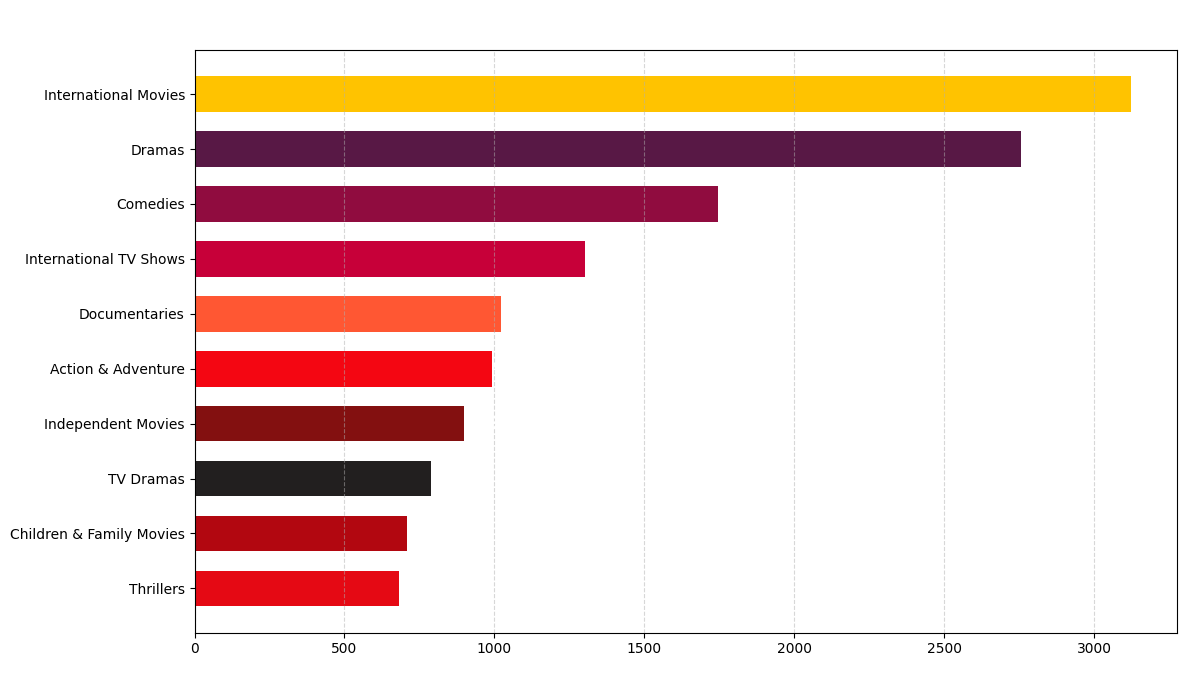

In [ ]:
fig, ax = plt.subplots(figsize=(12,7))  # نفس background اللي استخدمتيه قبل كده
colors_g = ['#E50914', '#B20710', '#221F1F', '#831010', '#F40612', '#FF5733', '#C70039', '#900C3F', '#581845', '#FFC300']

bars = ax.barh(top_genres.index[::-1], top_genres.values[::-1],
               color=colors_g, edgecolor='none', height=0.65)

# إضافة أرقام على الأعمدة
for bar, val in zip(bars, top_genres.values[::-1]):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            str(val), va='center', color='white', fontsize=12, fontweight='bold')

# Labels & Title
ax.set_xlabel('Number of Titles', fontsize=13, color='white')
ax.set_title('Top 10 Genres / Categories', fontsize=17, fontweight='bold', color='white', pad=15)

# Grid
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
df['title'].value_counts().head(10)

,count
title,
Barbecue,12
The Look of Silence,10
The Professor and the Madman,8
The Take,7
Arctic Dogs,7
The Breadwinner,7
Domino,7
The Congress,7
Frozen Planet: The Epic Journey,6


In [ ]:
df['unique_title'] = df['title'] + " (" + df['release_year'].astype(str) + ")"

In [ ]:
df.duplicated(subset='title').sum()

np.int64(1783)

**Delete the duplicates**

In [ ]:
#df = df.drop_duplicates(subset='title').reset_index(drop=True)

# **Creating a Combined Text Feature**

To perform clustering on Netflix content, we need a textual representation for each title.

In this step we:

- Inspect the structure of the **genre column (`listed_in`)**
- Convert genres into a clean text format
- Combine **genres** and **description** into a single feature called `text_feature`

This combined text will later be used for **NLP processing and vectorization**.
Code

In [ ]:
# Check the data type of the genre column
print(type(df['listed_in'].iloc[0]))
# Convert genre lists into a single text string if needed
df['listed_in1'] = df['listed_in'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)
# Display an example of the processed genre column
df['listed_in1'][2]
# Display an example description
print(df['description'].iloc[0])
# Combine genre and description into one text feature
df['text_feature']=df['listed_in1'].fillna(' ').str.lower().replace(',',' ')+' '+df['description'].fillna(' ').str.lower()
# Show an example of the combined text
df['text_feature'][6]

<class 'str'>
In a future where the elite inhabit an island paradise far from the crowded slums, you get one chance to join the 3% saved from squalor.


'horror movies, international movies after an awful accident, a couple admitted to a grisly hospital are separated and must find each other to escape — before death finds them.'

## **Text Cleaning**

Before applying machine learning algorithms, we clean the text data.

The preprocessing steps include:

- Converting text to lowercase
- Removing punctuation
- Removing numbers
- Removing extra spaces
- Removing common stopwords (such as "the", "and", "is")

This helps reduce noise and improves the quality of the text features used for clustering.

**___________________________________________________**

In [ ]:
# Convert text to lowercase
df['text_feature']=df['text_feature'].str.lower()
# Remove punctuation
df['text_feature']=df['text_feature'].apply(lambda x :re.sub(r'[^\w\s]','',x))
# Remove numbers
df['text_feature']=df['text_feature'].apply(lambda x : re.sub(r'[\d+]','',x))
# Remove extra spaces
df['text_feature']=df['text_feature'].str.strip().str.replace(r'\s+',' ',regex=True)
# Download stopwords
nltk.download('stopwords')
# Load stopwords list
stop_words=set(stopwords.words('english'))
# Remove stopwords from text
df['text_feature']=df['text_feature'].apply(lambda x : ' '.join(word for word in x.split() if word not in stop_words ))
# Show sample stopwords
print(list(stop_words)[:10])

["mightn't", 'down', 'yourself', "hadn't", 'ain', 'of', "he'd", 'up', 'after', "shan't"]


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## **Text Normalization using Lemmatization**

To further improve the quality of our textual features, we perform **lemmatization**:

- Converts words to their **base form** (e.g., "running" → "run", "studies" → "study")
- Reduces the vocabulary size, which improves the **TF-IDF vectorization** and clustering results
- Helps focus on the meaning of words rather than grammatical variations

In [ ]:
# Download necessary NLTK resources
nltk.download('wordnet')
nltk.download('omw-1.4')
# Initialize the WordNet Lemmatizer
lemmatizer=WordNetLemmatizer()
# Apply lemmatization to the text_feature column
df['text_feature']=df['text_feature'].apply(lambda x:' '.join(lemmatizer.lemmatize(word) for word in x.split()))
# Display the first row to compare original description and lemmatized text
df[['description','text_feature']].head(1)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,description,text_feature
0,In a future where the elite inhabit an island ...,international tv show tv drama tv scifi fantas...


## **Text Feature Refinement**

After the initial text cleaning, we perform additional refinements to improve the quality of the textual features.

The following steps are applied:

- Remove very common platform-related words such as **tv**
- Remove generic media words such as **movie, show, series, film**
- Normalize spacing in the text
- Compare original descriptions with the cleaned text

Removing these generic terms helps the clustering model focus on **meaningful keywords** instead of platform-related words.

In [ ]:
# Remove the word "tv" from the text feature
df['text_feature']=df['text_feature'].str.replace('tv',' ')
# Normalize spaces
df['text_feature'] = df['text_feature'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

In [ ]:
# Compare original descriptions with cleaned text
for i in range(5):
    print(f"Original Description {i+1}: {df['description'].iloc[i]}")
    print(f"Cleaned Text {i+1}: {df['text_feature'].iloc[i]}")
    print("="*80)

Original Description 1: In a future where the elite inhabit an island paradise far from the crowded slums, you get one chance to join the 3% saved from squalor.
Cleaned Text 1: international show drama scifi fantasy future elite inhabit island paradise far crowded slum get one chance join saved squalor
Original Description 2: After a devastating earthquake hits Mexico City, trapped survivors from all walks of life wait to be rescued while trying desperately to stay alive.
Cleaned Text 2: drama international movie devastating earthquake hit mexico city trapped survivor walk life wait rescued trying desperately stay alive
Original Description 3: When an army recruit is found dead, his fellow soldiers are forced to confront a terrifying secret that's haunting their jungle island training camp.
Cleaned Text 3: horror movie international movie army recruit found dead fellow soldier forced confront terrifying secret thats haunting jungle island training camp
Original Description 4: In a post

In [ ]:
# Words that do not add useful meaning for clustering
unwanted_words=['movie','show','series','film']
# Remove these words from the text feature
df['text_feature']=df['text_feature'].apply(lambda x :' '.join(word for word in x.split()if word not in unwanted_words))
# Normalize spacing again
df['text_feature']=df['text_feature'].apply(lambda x : re.sub(r'\s+',' ',x).strip())

## **TF-IDF Vectorization**

We transform the cleaned and lemmatized text into a **numerical representation** using **TF-IDF**:

- TF-IDF measures **word importance** in a document relative to the corpus
- We limit the vocabulary to the **top 5000 features** to reduce dimensionality
- The resulting TF-IDF matrix will be used for clustering

In [ ]:

# Initialize TF-IDF vectorizer
tdifd=TfidfVectorizer(max_features=5000)
# Fit and transform the text_feature column
X=tdifd.fit_transform(df['text_feature'])
print("Shape of TF-IDF matrix:", X.shape)

Shape of TF-IDF matrix: (9560, 5000)


In [ ]:
# Convert first 5 rows to a DataFrame for inspection
feature_names = tdifd.get_feature_names_out()
df_tfidf_sample = pd.DataFrame(X[:5].toarray(), columns=feature_names)
print(df_tfidf_sample.head())

   aaron  abandon  abandoned  abargil  abbey  abduct  abducted  abduction  \
0    0.0      0.0        0.0      0.0    0.0     0.0       0.0        0.0   
1    0.0      0.0        0.0      0.0    0.0     0.0       0.0        0.0   
2    0.0      0.0        0.0      0.0    0.0     0.0       0.0        0.0   
3    0.0      0.0        0.0      0.0    0.0     0.0       0.0        0.0   
4    0.0      0.0        0.0      0.0    0.0     0.0       0.0        0.0   

   abductor  abducts  ...  zack  zane  zany  zealand  zev  zoe  zombie  zone  \
0       0.0      0.0  ...   0.0   0.0   0.0      0.0  0.0  0.0     0.0   0.0   
1       0.0      0.0  ...   0.0   0.0   0.0      0.0  0.0  0.0     0.0   0.0   
2       0.0      0.0  ...   0.0   0.0   0.0      0.0  0.0  0.0     0.0   0.0   
3       0.0      0.0  ...   0.0   0.0   0.0      0.0  0.0  0.0     0.0   0.0   
4       0.0      0.0  ...   0.0   0.0   0.0      0.0  0.0  0.0     0.0   0.0   

   zozo  zulu  
0   0.0   0.0  
1   0.0   0.0  
2   0.0 

## **Top Words per Film**

We identify the **top 10 words** with the highest TF-IDF score for each film:

- Helps us understand which words are **most important** in representing each movie or TV show
- These words will guide the clustering algorithm

In [ ]:
# Get feature names
feature_names = tdifd.get_feature_names_out()
# Display top 10 words for the first 5 films
for i in range(5):
    row = X[i].toarray().flatten()
    top_n_idx = row.argsort()[-10:][::-1]  # indices of top 10 words
    top_words = [(feature_names[idx], row[idx]) for idx in top_n_idx if row[idx] > 0]
    print(f"Top words for film {i+1}: {top_words}")
    print("-"*60)

Top words for film 1: [('crowded', np.float64(0.3703666511295498)), ('saved', np.float64(0.3435573785474525)), ('paradise', np.float64(0.32698475775582203)), ('slum', np.float64(0.32430334213593964)), ('far', np.float64(0.2899056153479698)), ('elite', np.float64(0.258068314375503)), ('island', np.float64(0.254171346505872)), ('chance', np.float64(0.2496179771896145)), ('future', np.float64(0.2323300338755505)), ('join', np.float64(0.22541915599683626))]
------------------------------------------------------------
Top words for film 2: [('rescued', np.float64(0.32540346043167984)), ('wait', np.float64(0.3194131293085431)), ('earthquake', np.float64(0.30555265837248574)), ('walk', np.float64(0.2872882084757164)), ('desperately', np.float64(0.2827111324286915)), ('alive', np.float64(0.27491302272281504)), ('devastating', np.float64(0.26554140933590875)), ('survivor', np.float64(0.24624975694688508)), ('stay', np.float64(0.24624975694688508)), ('trapped', np.float64(0.24001880442570322))]


## Dimensionality Reduction using Truncated SVD

After applying TF-IDF vectorization, the dataset contains a large number of features (up to 5000).

To improve computational efficiency and clustering performance, we apply **Truncated Singular Value Decomposition (SVD)**:

- Reduces the number of dimensions
- Preserves the most important information in the data
- Helps clustering algorithms perform better on high-dimensional text data

In this step, we reduce the TF-IDF matrix from **5000 features to 50 components**.

In [ ]:
# Apply dimensionality reduction using Truncated SVD
svd = TruncatedSVD(n_components=50, random_state=42)
# Transform the TF-IDF matrix
X_reduced = svd.fit_transform(X)
# Display the new shape after dimensionality reduction
print("Shape after dimensionality reduction:", X_reduced.shape)

# Reduce TF-IDF feature space to 50 dimensions while preserving important patterns

Shape after dimensionality reduction: (9560, 50)


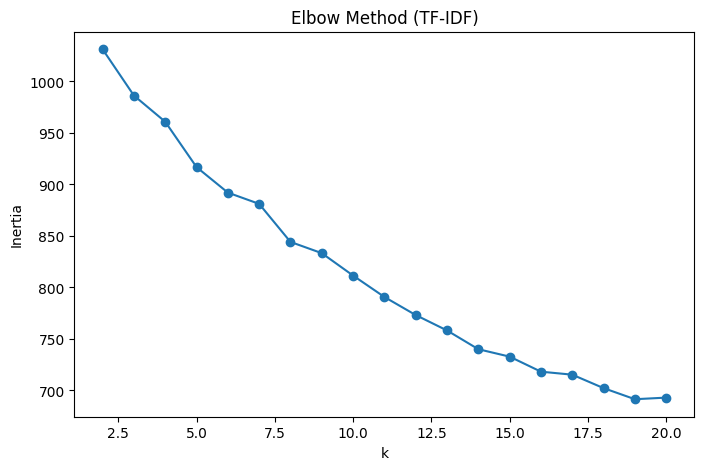

In [ ]:
inertia = []
k_values = range(2, 21)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_reduced)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_values, inertia, marker='o')
plt.title("Elbow Method (TF-IDF)")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

## K-Means Clustering

After reducing the dimensionality of the TF-IDF features, we apply **K-Means clustering** to group similar movies and TV shows together.

K-Means works by:
- Dividing the dataset into **K clusters**
- Grouping items with similar textual features
- Assigning each title to the nearest cluster center

In this step:
- We set the number of clusters to **12**
- Train the K-Means model on the reduced feature matrix
- Assign each movie or show to a cluster

In [ ]:
k = 12
# Initialize KMeans model
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
# Train the model on the reduced feature matrix
kmeans.fit(X_reduced)
# Assign cluster labels to the dataset
df['cluster_reduced'] = kmeans.labels_

In [ ]:
print(df['cluster_reduced'].value_counts())

cluster_reduced
8     2590
2     1099
10     901
1      894
9      796
0      690
4      556
5      499
3      498
11     386
6      365
7      286
Name: count, dtype: int64


## Clustering Evaluation using Silhouette Score

To evaluate the quality of the clustering results, we use the **Silhouette Score**.

The Silhouette Score measures how well each data point fits within its cluster compared to other clusters.

- The score ranges from **-1 to 1**
- **Closer to 1** → well-separated clusters
- **Around 0** → overlapping clusters
- **Negative values** → incorrect clustering

This metric helps determine whether the chosen number of clusters is appropriate.

In [ ]:
# Calculate Silhouette Score to evaluate clustering quality
score = silhouette_score(X_reduced, df['cluster_reduced'])
print("Silhouette Score after dimensionality reduction:", score)

Silhouette Score after dimensionality reduction: 0.11327510974920105


## Cluster Visualization

To better understand the clustering results, we visualize the clusters using a scatter plot.

Since the data has been reduced using **Truncated SVD**, we can plot the first two components:

- Each point represents a **movie or TV show**
- Colors represent **different clusters**
- Points that appear close together share similar textual features

This visualization helps us see how well the clusters are separated.

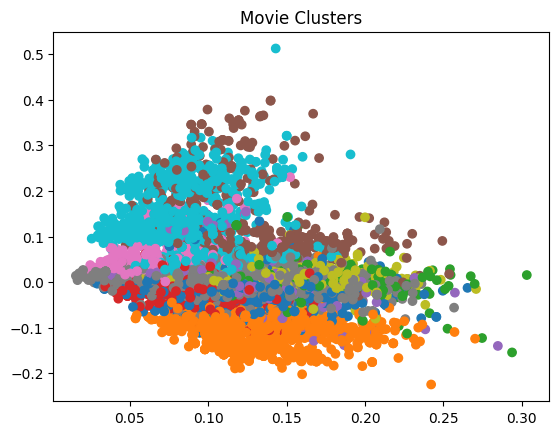

In [ ]:
# Visualize clusters
plt.scatter(X_reduced[:,0], X_reduced[:,1], c=df['cluster_reduced'], cmap='tab10')
plt.title("Movie Clusters")
plt.show()

In [ ]:
for i in range(10):
    print("="*40)
    print(f"Cluster {i}")
    print(df[df['cluster_reduced']==i][['title','text_feature']].head(3))

Cluster 0
                   title                                       text_feature
29              #blackAF  comedy kenya barris family navigate relationsh...
113  48 Christmas Wishes  child family comedy small town letter santa ac...
145         A 2nd Chance  child family drama sport gymnast lack confiden...
Cluster 1
   title                                       text_feature
2  23:59  horror international army recruit found dead f...
6    122  horror international awful accident couple adm...
8    706  horror international doctor go missing psychia...
Cluster 2
           title                                       text_feature
3              9  action adventure independent scifi fantasy pos...
21  ​Goli Soda 2  action adventure drama international taxi driv...
44      Æon Flux  action adventure scifi fantasy aiming hasten u...
Cluster 3
             title                                       text_feature
15          Oct-01  drama international thriller backdrop nigeria ...
39  

In [ ]:
cluster_counts = df['cluster_reduced'].value_counts().sort_index()

for cluster, count in cluster_counts.items():
    print(f"Cluster {cluster}: {count} movies")

Cluster 0: 690 movies
Cluster 1: 894 movies
Cluster 2: 1099 movies
Cluster 3: 498 movies
Cluster 4: 556 movies
Cluster 5: 499 movies
Cluster 6: 365 movies
Cluster 7: 286 movies
Cluster 8: 2590 movies
Cluster 9: 796 movies
Cluster 10: 901 movies
Cluster 11: 386 movies


In [ ]:
for i in range(k):
    print("="*50)
    print(f"Cluster {i} examples:")

    examples = df[df['cluster_reduced'] == i][['title','listed_in']].head(5)

    for index, row in examples.iterrows():
        print(f"{row['title']}  -->  {row['listed_in']}")

Cluster 0 examples:
#blackAF  -->  TV Comedies
48 Christmas Wishes  -->  Children & Family Movies, Comedies
A 2nd Chance  -->  Children & Family Movies, Dramas, Sports Movies
A Babysitter's Guide to Monster Hunting  -->  Children & Family Movies
A Billion Colour Story  -->  Dramas, Independent Movies, International Movies
Cluster 1 examples:
23:59  -->  Horror Movies, International Movies
122  -->  Horror Movies, International Movies
706  -->  Horror Movies, International Movies
1920  -->  Horror Movies, International Movies, Thrillers
1922  -->  Dramas, Thrillers
Cluster 2 examples:
9  -->  Action & Adventure, Independent Movies, Sci-Fi & Fantasy
​Goli Soda 2  -->  Action & Adventure, Dramas, International Movies
Æon Flux  -->  Action & Adventure, Sci-Fi & Fantasy
10,000 B.C.  -->  Action & Adventure
10,000 B.C.  -->  Action & Adventure
Cluster 3 examples:
Oct-01  -->  Dramas, International Movies, Thrillers
¡Ay, mi madre!  -->  Comedies, International Movies
Òlòtūré  -->  Dramas, Int

In [ ]:
print(df['cluster_reduced'].value_counts())

cluster_reduced
8     2590
2     1099
10     901
1      894
9      796
0      690
4      556
5      499
3      498
11     386
6      365
7      286
Name: count, dtype: int64


In [ ]:
df['unique_title'] = df['title'] + " (" + df['release_year'].astype(str) + ")"


for i in range(k):
    print("="*50)
    print(f"Cluster {i} examples:")


    examples = df[df['cluster_reduced'] == i][['unique_title', 'listed_in']]

    examples = examples.drop_duplicates(subset='unique_title')

    examples = examples.head(5)

    for index, row in examples.iterrows():
        print(f"{row['unique_title']}  -->  {row['listed_in']}")

Cluster 0 examples:
#blackAF (2020)  -->  TV Comedies
48 Christmas Wishes (2017)  -->  Children & Family Movies, Comedies
A 2nd Chance (2011)  -->  Children & Family Movies, Dramas, Sports Movies
A Babysitter's Guide to Monster Hunting (2020)  -->  Children & Family Movies
A Billion Colour Story (2016)  -->  Dramas, Independent Movies, International Movies
Cluster 1 examples:
23:59 (2011)  -->  Horror Movies, International Movies
122 (2019)  -->  Horror Movies, International Movies
706 (2019)  -->  Horror Movies, International Movies
1920 (2008)  -->  Horror Movies, International Movies, Thrillers
1922 (2017)  -->  Dramas, Thrillers
Cluster 2 examples:
9 (2009)  -->  Action & Adventure, Independent Movies, Sci-Fi & Fantasy
​Goli Soda 2 (2018)  -->  Action & Adventure, Dramas, International Movies
Æon Flux (2005)  -->  Action & Adventure, Sci-Fi & Fantasy
10,000 B.C. (2008)  -->  Action & Adventure
14 Blades (2010)  -->  Action & Adventure, International Movies
Cluster 3 examples:
Oct-0

In [ ]:
cluster_names = {
0:"Documentaries",
1:"Comedy",
2:"Drama",
3:"Musicals",
4:"TV Drama",
5:"Action",
6:"Family",
7:"Sci-Fi",
8:"Kids TV",
9:"Crime Thriller",
10:"Horror",
11:"Docuseries / Reality"
}

## Top Words per Cluster

To understand the themes represented by each cluster, we extract the **top words** with the highest average TF-IDF scores within each cluster.

Steps:
- Identify all titles belonging to each cluster
- Compute the **average TF-IDF score** for each word
- Sort the words by importance
- Display the **top 10 words** representing the cluster

These words help interpret the **main topic or genre** of each cluster.

In [ ]:
terms =tdifd.get_feature_names_out()

for i in range(k):
    print("="*50)
    print(f"Cluster {i} Top Words:")

    cluster_indices = np.where(df['cluster_reduced'] == i)[0]

    if len(cluster_indices) == 0:
        print("Empty cluster")
        continue

    mean_tfidf = X[cluster_indices].mean(axis=0).A1

    top_indices = mean_tfidf.argsort()[::-1][:10]
    top_words = [terms[ind] for ind in top_indices]

    print(", ".join(top_words))

Cluster 0 Top Words:
child, family, comedy, save, get, new, friend, christmas, help, must
Cluster 1 Top Words:
thriller, horror, international, drama, independent, scifi, murder, fantasy, find, home
Cluster 2 Top Words:
action, adventure, scifi, international, fantasy, drama, comedy, agent, must, find
Cluster 3 Top Words:
woman, drama, international, young, romantic, life, comedy, man, husband, independent
Cluster 4 Top Words:
kid, friend, adventure, comedy, power, world, new, evil, ranger, fun
Cluster 5 Top Words:
crime, international, drama, docuseries, detective, spanishlanguage, murder, drug, case, police
Cluster 6 Top Words:
music, musical, documentary, international, comedy, band, drama, love, family, tour
Cluster 7 Top Words:
docuseries, nature, science, british, world, international, history, reality, explores, animal
Cluster 8 Top Words:
drama, international, comedy, independent, life, reality, family, find, young, man
Cluster 9 Top Words:
romantic, international, love, comedy

## Word2Vec Embeddings

In addition to TF-IDF, we generate **Word2Vec embeddings** for each movie description.

Steps:
1. Tokenize each movie description into words
2. Train a Word2Vec model on all tokens
3. Represent each movie as the **average of its word vectors**
4. This produces a **dense embedding vector** for each movie, useful for clustering or recommendations

Advantages:
- Captures **semantic similarity** between words
- Works better for context-aware similarity compared to TF-IDF

In [ ]:
!pip install gensim
from gensim.models import Word2Vec
df['tokens'] = df['text_feature'].apply(lambda x: x.split())
w2v_model = Word2Vec(
    sentences=df['tokens'],
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    seed=42
)
def get_embedding(tokens, model):
    vectors = []
    for word in tokens:
        if word in model.wv:
            vectors.append(model.wv[word])
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

X_embed = np.array([get_embedding(tokens, w2v_model) for tokens in df['tokens']])

print("Embedding shape:", X_embed.shape)

Embedding shape: (9560, 100)


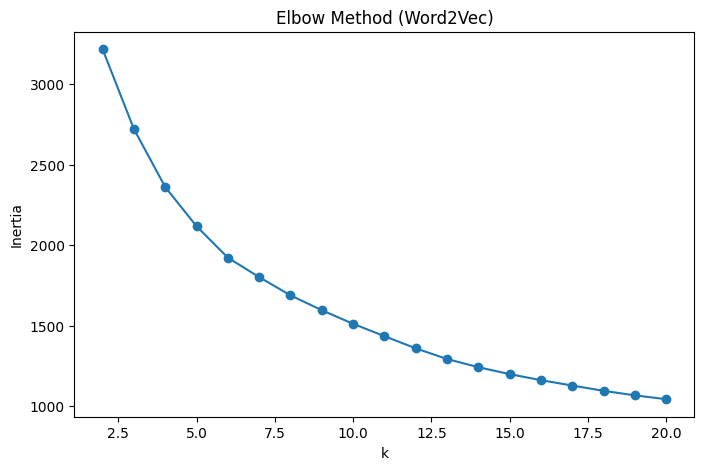

In [ ]:
inertia = []
k_values = range(2, 21)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_embed)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_values, inertia, marker='o')
plt.title("Elbow Method (Word2Vec)")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

## K-Means Clustering on Word2Vec Embeddings

We can use the dense Word2Vec embeddings to cluster movies:

- `X_embed` contains **movie-level embeddings** (average of word vectors)
- We apply **K-Means clustering** to group similar movies
- The resulting clusters are stored in `df['cluster_embed']`

This approach often captures **semantic similarity** better than TF-IDF, especially for movies with similar topics but different wording.

In [ ]:
k = 12

kmeans_embed = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_embed = kmeans_embed.fit_predict(X_embed)

df['cluster_embed'] = labels_embed

In [ ]:
score_embed = silhouette_score(X_embed, labels_embed)
print("Silhouette Score using Embedding:", score_embed)

Silhouette Score using Embedding: 0.19778067


In [ ]:
df['cluster_embed'].value_counts().sort_index()

,count
cluster_embed,
0,1552
1,565
2,1083
3,309
4,676
5,1029
6,681
7,826
8,290


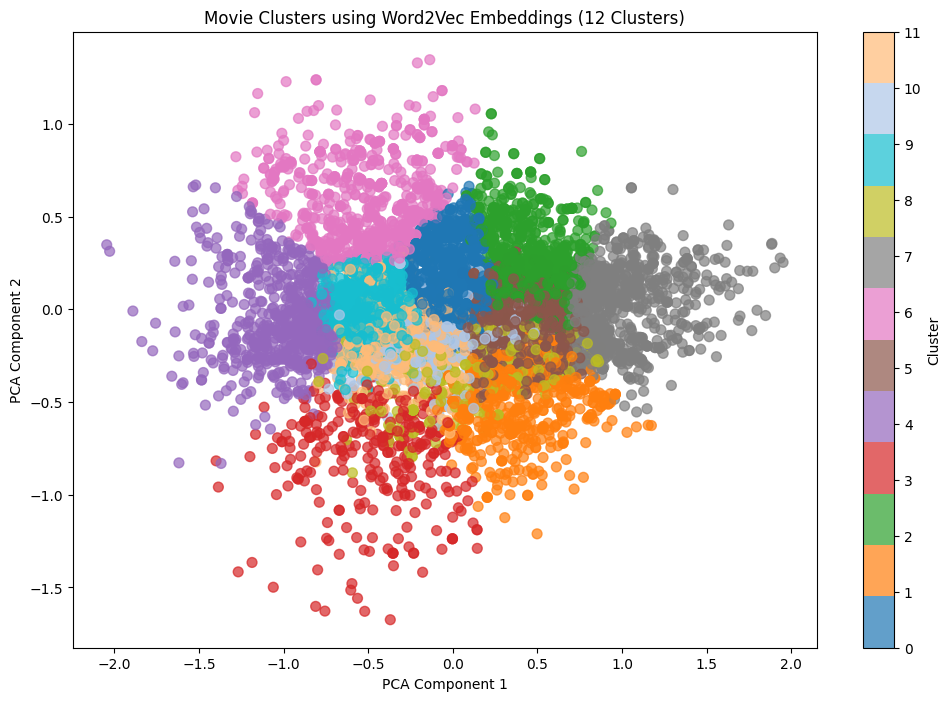

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

pca = PCA(n_components=2, random_state=42)
X_embed_2d = pca.fit_transform(X_embed)

colors = ListedColormap([
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
    '#aec7e8', '#ffbb78'
])

plt.figure(figsize=(12,8))
scatter = plt.scatter(
    X_embed_2d[:,0], X_embed_2d[:,1],
    c=df['cluster_embed'], cmap=colors, s=50, alpha=0.7
)

plt.title("Movie Clusters using Word2Vec Embeddings (12 Clusters)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
cbar = plt.colorbar(scatter, ticks=np.arange(0,12))
cbar.set_label("Cluster")
plt.show()

## Comparing Clustering Methods

We compare the quality of clustering between:

1. **TF-IDF vectorization** (`score`)
2. **Word2Vec embeddings** (`score_embed`)

We use **Silhouette Score** as the evaluation metric:

- Higher score → better-defined clusters
- This helps decide which representation captures movie similarity better

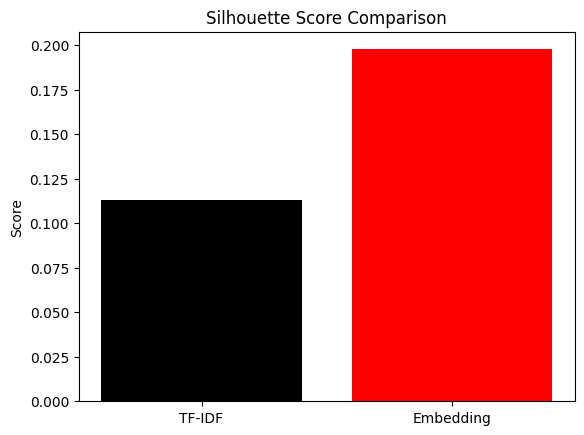

In [ ]:
methods = ['TF-IDF', 'Embedding']
scores = [score, score_embed]

plt.bar(methods, scores, color=['black', 'red'])
plt.title("Silhouette Score Comparison")
plt.ylabel("Score")
plt.show()

## Recommendation System with Word2Vec Embeddings

Steps:

1. Select a movie
2. Identify its cluster from `cluster_embed`
3. Compute **cosine similarity** between the movie and all movies in the same cluster using embeddings
4. Sort by similarity and return the **top N recommendations**
5. Display:
   - Movie title
   - Genres
   - Top words (from the movie description)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def recommend_movies_w2v(movie_title, df, X_embed, top_n=10):

    if movie_title not in df['title'].values:
        print("Movie not found!")
        return

    movie_idx = df[df['title'] == movie_title].index[0]
    movie_cluster = df.loc[movie_idx, 'cluster_embed']

    cluster_indices = df[df['cluster_embed'] == movie_cluster].index
    cluster_vectors = X_embed[cluster_indices]
    movie_vector = X_embed[movie_idx].reshape(1, -1)

    similarities = cosine_similarity(movie_vector, cluster_vectors).flatten()

    sorted_idx = np.argsort(similarities)[::-1]
    similar_indices = cluster_indices[sorted_idx]

    similar_indices = similar_indices[similar_indices != movie_idx]

    top_movies = df.loc[similar_indices]

    top_movies = top_movies.drop_duplicates(subset='unique_title')

    top_movies = top_movies.head(top_n)

    print(f"\n🎬 Recommendations for '{movie_title}':\n")

    for i, row in enumerate(top_movies.itertuples(), 1):

        top_words = row.tokens[:5]

        print(f"{i}. {row.unique_title}")
        print(f"   Genres: {row.listed_in}")
        print(f"   Key Words: {', '.join(top_words)}\n")

In [ ]:
recommend_movies_w2v("23:59", df, X_embed, top_n=10)


🎬 Recommendations for '23:59':

1. Power Rangers Zeo (1996)
   Genres: Kids' TV
   Key Words: kid, mighty, morphin, power, ranger

2. Power Rangers: Megaforce (2013)
   Genres: Kids' TV
   Key Words: kid, earth, threatened, massive, alien

3. Ultimate Beastmaster México (2018)
   Genres: Reality TV, Spanish-Language TV Shows
   Key Words: reality, spanishlanguage, competitor, representing, country

4. Barbie: Princess Charm School (2011)
   Genres: Children & Family Movies
   Key Words: child, family, blair, willow, excited

5. Santa Banta Pvt Ltd (2016)
   Genres: Comedies, International Movies
   Key Words: comedy, international, passed, spy, two

6. Monster High: Ghouls Rule (2012)
   Genres: Children & Family Movies
   Key Words: child, family, learning, monster, normies

7. Jake's Buccaneer Blast (2014)
   Genres: Movies
   Key Words: jake, izzy, cubby, skully, face

8. Wine Country (2019)
   Genres: Comedies
   Key Words: comedy, longtime, friend, meet, winesoaked

9. Anthony Je